# Fase 3.0 — Valor del Feature Extractor COS: COS vs MLP estàndard

**Objectiu:** Determinar si l'arquitectura `CosMultiInputSB3` aporta millora de rendiment respecte a un MLP estàndard de SB3, en tres protocols d'entrenament.

**Disseny experimental:**
- **2 algorismes**: DQN-SB3, PPO-SB3
- **3 protocols**: `control` (24M partides), `curriculum` (12M mans + 12M partides), `mans` (24M mans)
- **2 variants** per protocol: `cos` (CosMultiInputSB3, init scratch), `mlp` (MLP estàndard SB3)
- Oponent: 10% Random + 90% AgentRegles (sense self-play)
- Avaluació: 100 partides senceres (`TrucGymEnv`) cada 500 000 steps

| Protocol | Variant | Entorn entrenament | Feature extractor | Origen dades |
|:--|:--|:--|:--|:--|
| control | cos | TrucGymEnv (24M) | CosMultiInputSB3 scratch | Fase 30 (nova) |
| control | mlp | TrucGymEnv (24M) | MLP estàndard SB3 | **Fase 2 control** |
| curriculum | cos | TrucGymEnvMa (12M) + TrucGymEnv (12M) | CosMultiInputSB3 scratch | Fase 30 (nova) |
| curriculum | mlp | TrucGymEnvMa (12M) + TrucGymEnv (12M) | MLP estàndard SB3 | **Fase 2 curriculum** |
| mans | cos | TrucGymEnvMa (24M) | CosMultiInputSB3 scratch | Fase 30 |
| mans | mlp | TrucGymEnvMa (24M) | MLP estàndard SB3 | Fase 30 (nova) |

**Resultats clau (pic eval_metric):**

| Agent | Protocol | COS | MLP | Δ (COS − MLP) |
|:--|:--|:--|:--|:--|
| DQN-SB3 | control | 71.0% | 60.5% | **+10.5 pp** |
| DQN-SB3 | curriculum | 56.2% | 56.0% | +0.2 pp |
| DQN-SB3 | mans | 82.2% | **85.8%** | −3.6 pp |
| PPO-SB3 | control | 32.5% | **35.0%** | −2.5 pp |
| PPO-SB3 | curriculum | 63.0% | **75.0%** | −12.0 pp |
| PPO-SB3 | mans | **89.0%** | 87.2% | +1.8 pp |

**Conclusió:** COS no aporta un benefici consistent. Per a DQN ajuda en control (+10.5 pp); per a PPO el MLP és millor en control i curriculum, mentre que en mans ambdues variants superen el 85%.

---

## 1. Context teòric

### 1.1 Arquitectura CosMultiInputSB3

`CosMultiInputSB3` és un feature extractor personalitzat per a SB3 que divideix el vector d'observació de 240 dimensions en dues branques:
- **Branca CNN** sobre el mapa de cartes `(6, 4, 9)`: dues capes Conv2d → Flatten → **320 dims**
- **Branca densa** sobre el context `(24,)`: Linear(24→32) + ReLU → **32 dims**
- **Fusió**: Linear(352→256) + ReLU → sortida de **256 dims**

El MLP estàndard de SB3 (`CombinedExtractor`) processa el dict d'observació sense especialització: aplana totes les entrades i les concatena directament abans de passar-les per les capes MLP.

### 1.2 Hipòtesi

| Comparació | Hipòtesi | Risc |
|:--|:--|:--|
| COS > MLP (control) | La CNN del cos extreu representacions espacials de les cartes més riques que l'aplanament naïu | Overhead computacional sense guany si el MLP ja satura |
| COS > MLP (curriculum) | El cos especialitzat + curriculum pot superar MLP + curriculum | Si el MLP ja aprofita prou el curriculum, el COS no aporta |
| COS > MLP (mans) | CNN + context és natural per a episodis d'una sola mà | El MLP pot ser suficient si l'estat per mà és simple |

### 1.3 Mètriques

- `eval_metric = 0.25 × WR_random + 0.75 × WR_regles` — mètrica principal
- `eval_wr_random` — % victòries contra agent aleatori
- `eval_wr_regles` — % victòries contra AgentRegles (oponent de referència)

---

## 2. Setup

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

sys.path.insert(0, str(Path('../../utils')))
from nb_utils import (setup_pyplot, suavitzar,
                      trobar_ultima_carpeta as _trobar,
                      step_first_above,
                      carregar_curriculum, carregar_dades_tag,
                      COLORS_AGENTS, LABELS_AGENTS,
                      COLORS_TAG, LABELS_TAG, LSTYLE_TAG, LWIDTH_TAG)

setup_pyplot()

AGENTS    = ['dqn_sb3', 'ppo_sb3']
PROTOCOLS = ['control', 'curriculum', 'mans']
TAGS      = ['cos', 'mlp']

LABELS_A = {'dqn_sb3': 'DQN-SB3', 'ppo_sb3': 'PPO-SB3'}
LABELS_P = {'control': 'Control (partides)', 'curriculum': 'Curriculum', 'mans': 'Mans'}

BASE = Path('../../../..')

def trobar_ultima_carpeta(patro: str) -> Path | None:
    return _trobar(patro, base=BASE)

print('Setup completat.')
print(f'Directori base: {BASE.resolve()}')

Setup completat.
Directori base: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc


---

## 3. Càrrega de dades

In [2]:
carpeta_f30 = BASE / 'TFG_Doc/notebooks/3_feature_extractor/resultats'

if not carpeta_f30.exists():
    print('No s\'ha trobat la carpeta de resultats de Fase 30.')
    dades_cos = {a: {} for a in AGENTS}
else:
    print(f'Carpeta Fase 30: {carpeta_f30}')
    dades_cos = carregar_dades_tag(carpeta_f30, AGENTS, PROTOCOLS, 'cos')
    for agent in AGENTS:
        for protocol in PROTOCOLS:
            df = dades_cos[agent].get(protocol)
            if df is not None:
                print(f'  {LABELS_A[agent]} {LABELS_P[protocol]:<25}: '
                      f'{len(df)} aval., max step={df["step"].max()/1e6:.0f}M, '
                      f'millor metric={df["eval_metric"].max():.1f}%')
    resum = carpeta_f30 / 'resum_fase3.txt'
    if resum.exists():
        print('\n' + resum.read_text())

Carpeta Fase 30: ..\..\..\..\TFG_Doc\notebooks\3_feature_extractor\resultats


  DQN-SB3 Control (partides)       : 48 aval., max step=24M, millor metric=71.0%
  DQN-SB3 Curriculum               : 24 aval., max step=24M, millor metric=56.2%
  PPO-SB3 Control (partides)       : 48 aval., max step=24M, millor metric=32.5%
  PPO-SB3 Curriculum               : 24 aval., max step=24M, millor metric=63.0%

Fase 3: Valor del Feature Extractor COS 
-------------------------------------------
ppo_sb3_control_cos: 2481s (0h 41m 21s)
dqn_sb3_control_cos: 19177s (5h 19m 37s)
ppo_sb3_curriculum_cos: 2484s (0h 41m 24s)
dqn_sb3_curriculum_cos: 19931s (5h 32m 11s)
ppo_sb3_mans_mlp: 2211s (0h 36m 51s)
dqn_sb3_mans_mlp: 12458s (3h 27m 38s)
dqn_sb3_scratch: 19817s (5h 30m 17s)
dqn_sb3_frozen: 17729s (4h 55m 29s)
dqn_sb3_finetune: 19861s (5h 31m 1s)
ppo_sb3_scratch: 2412s (0h 40m 12s)
ppo_sb3_frozen: 2336s (0h 38m 56s)
ppo_sb3_finetune: 2435s (0h 40m 35s)

 


In [3]:
# Referència control MLP → Fase 2 control
carpeta_f2_ctrl = trobar_ultima_carpeta('TFG_Doc/notebooks/2_curriculum_learning/resultats_fase2_control_*')
ref_ctrl_mlp = {}
if carpeta_f2_ctrl:
    for agent in AGENTS:
        path = carpeta_f2_ctrl / agent / 'training_log.csv'
        if path.exists():
            ref_ctrl_mlp[agent] = pd.read_csv(path)
    print(f'Referència control MLP (F2): {carpeta_f2_ctrl.name}')
    for agent, df in ref_ctrl_mlp.items():
        print(f'  {LABELS_A[agent]}: millor metric={df["eval_metric"].max():.1f}%')
else:
    print('No s\'ha trobat Fase 2 control.')

# Referència curriculum MLP → Fase 2 curriculum
carpeta_f2_curr = trobar_ultima_carpeta('TFG_Doc/notebooks/2_curriculum_learning/resultats_fase2_curriculum_*')
ref_curr_mlp = {}
if carpeta_f2_curr:
    for agent in AGENTS:
        df = carregar_curriculum(carpeta_f2_curr, agent)
        if df is not None:
            ref_curr_mlp[agent] = df
    print(f'\nReferència curriculum MLP (F2): {carpeta_f2_curr.name}')
    for agent, df in ref_curr_mlp.items():
        print(f'  {LABELS_A[agent]}: millor metric={df["eval_metric"].max():.1f}%')
else:
    print('No s\'ha trobat Fase 2 curriculum.')

# Mans COS
ref_mans_cos = {}
if carpeta_f30 and carpeta_f30.exists():
    for agent in AGENTS:
        path = carpeta_f30 / f'{agent}_scratch' / 'training_log.csv'
        if path.exists():
            ref_mans_cos[agent] = pd.read_csv(path)
    if ref_mans_cos:
        print('\nMans COS:')
        for agent, df in ref_mans_cos.items():
            print(f'  {LABELS_A[agent]}: millor metric={df["eval_metric"].max():.1f}%')

# Mans MLP → Fase 30
ref_mans_mlp = {}
if carpeta_f30 and carpeta_f30.exists():
    ref_mans_mlp = carregar_dades_tag(carpeta_f30, AGENTS, ['mans'], 'mlp')
    ref_mans_mlp = {a: d.get('mans') for a, d in ref_mans_mlp.items() if d.get('mans') is not None}
    if ref_mans_mlp:
        print('\nMans MLP:')
        for agent, df in ref_mans_mlp.items():
            print(f'  {LABELS_A[agent]}: millor metric={df["eval_metric"].max():.1f}%')

Referència control MLP (F2): resultats_fase2_control_11_04_1145h
  DQN-SB3: millor metric=60.5%
  PPO-SB3: millor metric=35.0%



Referència curriculum MLP (F2): resultats_fase2_curriculum_13_04_0947h
  DQN-SB3: millor metric=56.0%
  PPO-SB3: millor metric=75.0%

Mans COS:
  DQN-SB3: millor metric=82.2%
  PPO-SB3: millor metric=89.0%

Mans MLP:
  DQN-SB3: millor metric=85.8%
  PPO-SB3: millor metric=87.2%


---

## 4. Corbes d'aprenentatge per protocol

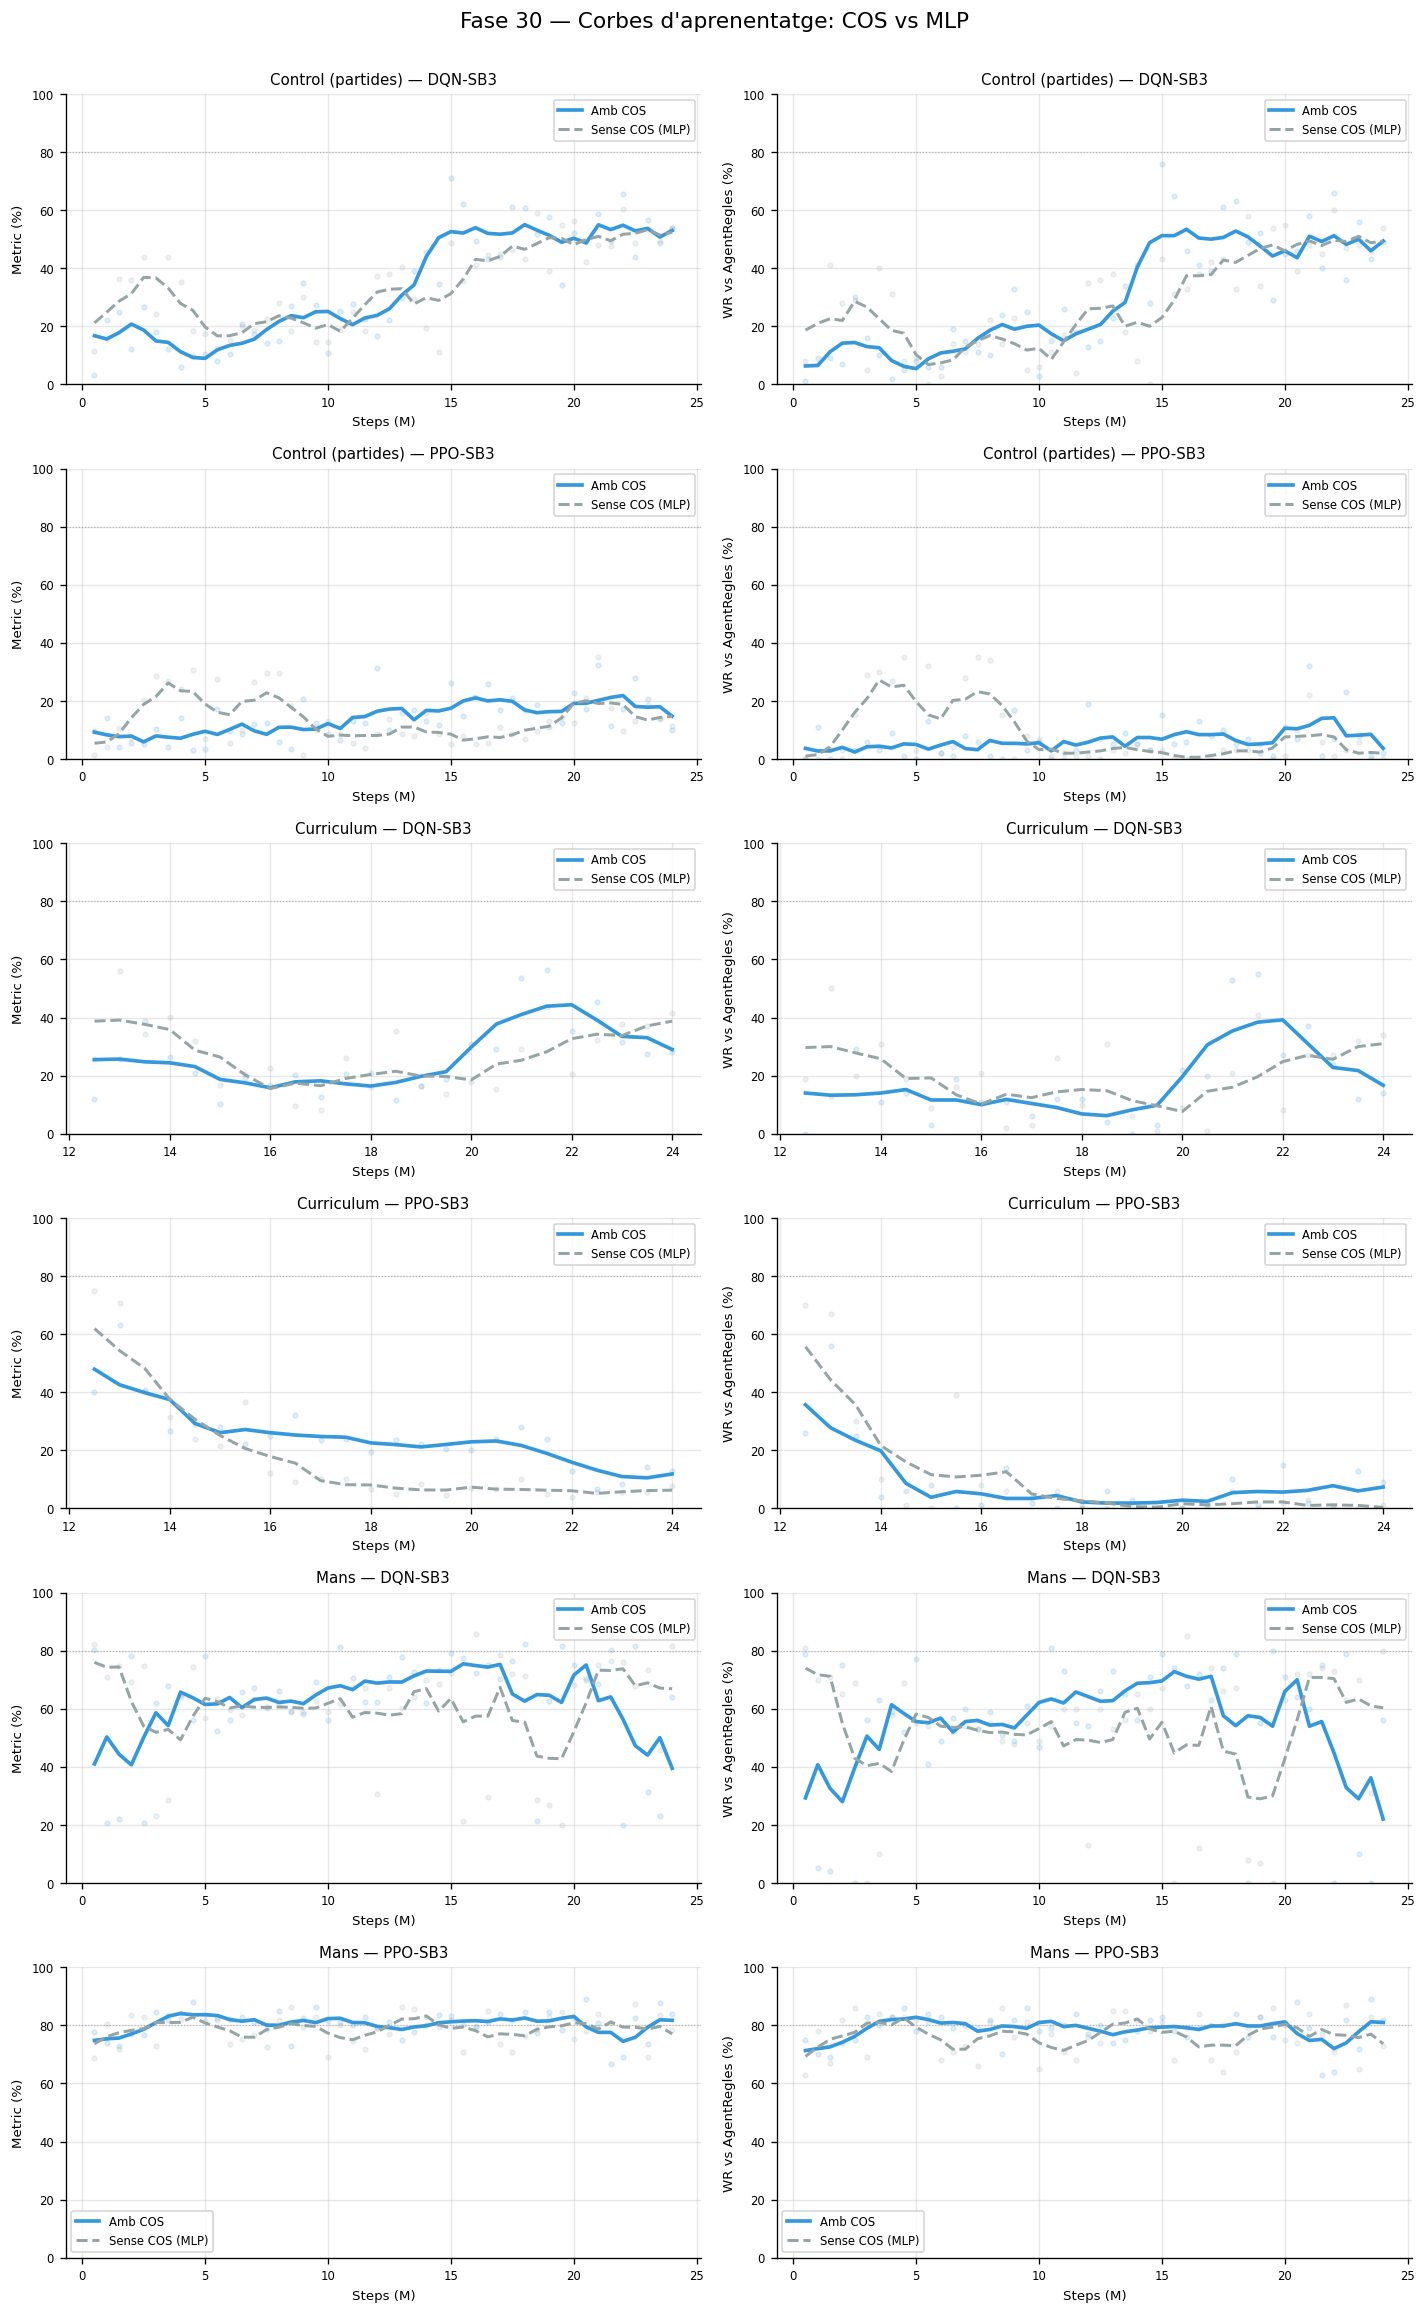

In [4]:
WINDOW = 5

def _get_df(protocol: str, tag: str, agent: str) -> pd.DataFrame | None:
    if tag == 'cos':
        df = dades_cos[agent].get(protocol)
        if df is None and protocol == 'mans':
            return ref_mans_cos.get(agent)
        return df
    if protocol == 'control':
        return ref_ctrl_mlp.get(agent)
    if protocol == 'curriculum':
        return ref_curr_mlp.get(agent)
    return ref_mans_mlp.get(agent)

METRIQUES  = [('eval_metric', 'Metric (%)'), ('eval_wr_regles', 'WR vs AgentRegles (%)')]
COMBINADES = [(p, a) for p in PROTOCOLS for a in AGENTS]

fig, axes = plt.subplots(len(COMBINADES), 2, figsize=(12, 3.2 * len(COMBINADES)))
fig.suptitle('Fase 30 — Corbes d\'aprenentatge: COS vs MLP', fontsize=13, y=1.002)

for row, (protocol, agent) in enumerate(COMBINADES):
    for col, (met, ylabel) in enumerate(METRIQUES):
        ax = axes[row][col]
        for tag in TAGS:
            df = _get_df(protocol, tag, agent)
            if df is None:
                continue
            s = df['step'] / 1e6
            ax.scatter(s, df[met], color=COLORS_TAG[tag], alpha=0.15, s=8)
            ax.plot(s, suavitzar(df[met], WINDOW),
                    color=COLORS_TAG[tag], linestyle=LSTYLE_TAG[tag],
                    linewidth=LWIDTH_TAG[tag], label=LABELS_TAG[tag])
        ax.set_title(f'{LABELS_P[protocol]} — {LABELS_A[agent]}', fontsize=9)
        ax.set_xlabel('Steps (M)', fontsize=8)
        ax.set_ylabel(ylabel, fontsize=8)
        ax.tick_params(labelsize=7)
        ax.set_ylim(0, 100)
        ax.axhline(80, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

---

## 5. Taula resum i barplot

In [5]:
rows = []
for agent in AGENTS:
    for protocol in PROTOCOLS:
        for tag in TAGS:
            df = _get_df(protocol, tag, agent)
            if df is None:
                continue
            pic      = df['eval_metric'].max()
            step_pic = df.loc[df['eval_metric'].idxmax(), 'step'] / 1e6
            temps_h  = df['elapsed_s'].max() / 3600 if 'elapsed_s' in df.columns else float('nan')
            rows.append({
                'Agent':           LABELS_A[agent],
                'Protocol':        LABELS_P[protocol],
                'Feature ext.':    LABELS_TAG[tag],
                'Pic metric (%)':  f'{pic:.1f}',
                'Step pic (M)':    f'{step_pic:.1f}',
                '≥80% (1r step)':  step_first_above(df, 80),
                '≥85% (1r step)':  step_first_above(df, 85),
                'Temps (h)':       f'{temps_h:.2f}' if not np.isnan(temps_h) else '—',
            })

df_resum = pd.DataFrame(rows).set_index(['Agent', 'Protocol', 'Feature ext.'])

def highlight_best(col):
    try:
        vals = col.str.rstrip('%').astype(float)
        is_max = vals == vals.max()
        return ['font-weight: bold; color: green' if v else '' for v in is_max]
    except Exception:
        return ['' for _ in col]

df_resum.style.apply(highlight_best, subset=['Pic metric (%)'])

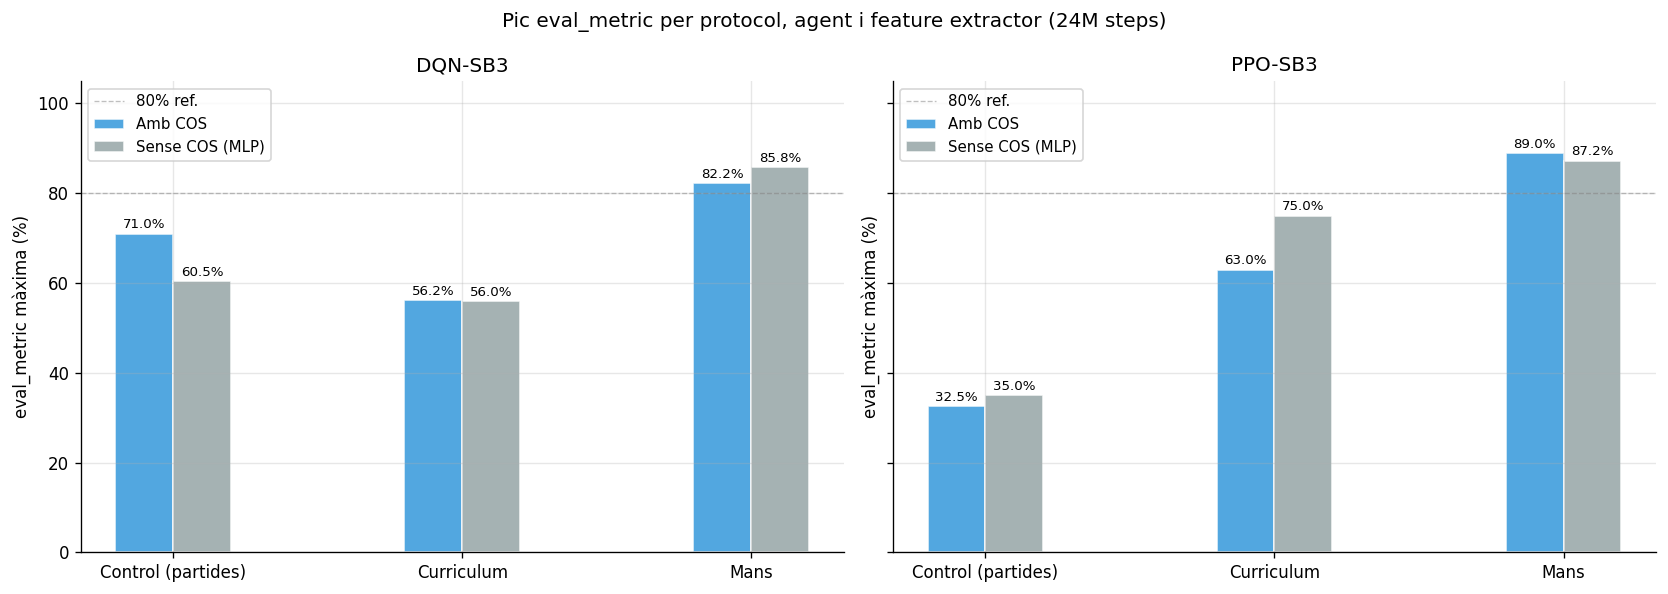

In [6]:
pics = {}
for agent in AGENTS:
    for protocol in PROTOCOLS:
        for tag in TAGS:
            df = _get_df(protocol, tag, agent)
            pics[(agent, protocol, tag)] = df['eval_metric'].max() if df is not None else float('nan')

x = np.arange(len(PROTOCOLS))
width = 0.20
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle('Pic eval_metric per protocol, agent i feature extractor (24M steps)', fontsize=12)

for ax, agent in zip(axes, AGENTS):
    for i, tag in enumerate(TAGS):
        vals = [pics.get((agent, p, tag), float('nan')) for p in PROTOCOLS]
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, vals, width,
                      label=LABELS_TAG[tag],
                      color=COLORS_TAG[tag],
                      alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                        f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

    ax.set_title(LABELS_A[agent], fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels([LABELS_P[p] for p in PROTOCOLS])
    ax.set_ylabel('eval_metric màxima (%)')
    ax.set_ylim(0, 105)
    ax.axhline(80, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='80% ref.')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Conclusions

### 6.1 Resum quantitatiu

| Agent | Protocol | COS (pic) | MLP (pic) | Δ (COS − MLP) |
|:--|:--|:--|:--|:--|
| DQN-SB3 | control | **71.0%** | 60.5% | **+10.5 pp** |
| DQN-SB3 | curriculum | 56.2% | 56.0% | +0.2 pp |
| DQN-SB3 | mans | 82.2% | **85.8%** | −3.6 pp |
| PPO-SB3 | control | 32.5% | **35.0%** | −2.5 pp |
| PPO-SB3 | curriculum | 63.0% | **75.0%** | −12.0 pp |
| PPO-SB3 | mans | **89.0%** | 87.2% | +1.8 pp |

---

### 6.2 Valor del COS

**Depèn de l'algorisme i del protocol. No hi ha un benefici consistent.**

- **DQN + control**: l'única combinació on COS és clarament millor (+10.5 pp, de 60.5% a 71.0%). La CNN del cos sembla ajudar DQN a representar millor el mapa de cartes en entrenament directe sobre partides.
- **DQN + curriculum**: COS i MLP empaten (56.2% vs 56.0%). El curriculum no magnifica ni anul·la el benefici de la CNN.
- **DQN + mans**: MLP supera COS (85.8% vs 82.2%, −3.6 pp). En episodis curts (una mà), el MLP és suficient i l'overhead de la CNN no aporta.
- **PPO + control**: tots dos convergen de manera deficient (32.5% vs 35.0%); ni COS ni MLP aprenen bé en 24M steps directes sobre partides.
- **PPO + curriculum**: MLP guanya amb marge ampli (75.0% vs 63.0%, +12 pp). El cos COS perjudica el finetune de la fase de partides, probablement perquè l'arquitectura afegeix paràmetres que dificulten l'adaptació ràpida en la fase 2 del curriculum.
- **PPO + mans**: COS és marginalment millor (89.0% vs 87.2%, +1.8 pp); ambdues variants superen el 85%.

---

### 6.3 Conclusió del COS

El **protocol control amb DQN** és l'únic cas on COS aporta una millora substancial (+10.5 pp). Tanmateix, la millor marca absoluta de DQN amb COS en control (71.0%) és inferior als resultats del protocol mans (MLP 85.8%, COS 82.2%), de manera que el guany relatiu no es tradueix en el millor agent absolut.

El **protocol mans** ofereix els millors resultats globals per a tots dos agents i les dues variants.

---

### 6.4 Decisió per a fases posteriors

| Criteri | Recomanació |
|:--|:--|
| Millor rendiment absolut | PPO-SB3 + mans + COS (89.0%) |
| Millor relació rendiment/complexitat | PPO-SB3 + mans + MLP (87.2%) |
| Millor per a DQN | DQN-SB3 + mans + MLP (85.8%) |

**Decisió**: El **protocol mans** és el que ofereix els millors resultats en tots els escenaris (>82% per a totes les combinacions). La tria entre COS i MLP per a PPO+mans és marginal (+1.8 pp); s'optarà per provar diverses tècniques per aprofitar millor el COS.